# FER-CNN — all experiments (Google Colab, GPU)

Clones the repo, downloads FER-2013 and FANE from Kaggle, runs the five
experiments of the study and mirrors the output to Drive.

| run | architecture | batch size | warm-up | trained part |
|---|---|---|---|---|
| `custom_cnn_bs32`, `custom_cnn_bs64` | ResNet-style CNN | 32, 64 | — | whole network, from scratch |
| `xception_1phase_bs32` | Xception | 32 | no | from `block14` on |
| `xception_2phase_bs32` | Xception | 32 | 5 epochs | from `block14` on |
| `xception_full_bs32` | Xception | 32 | 5 epochs | whole base |

`1phase` against `2phase` isolates the warm-up, `2phase` against `full` the
depth of the fine-tuning. Xception runs at batch size 32 only, so the batch
size comparison covers the custom CNN alone.

## Output

The Drive folder mirrors the project tree. Unpacking it over the repo root puts
every file in the folder it belongs to.

```
fer-cnn-results/
├── models_saved/     run checkpoints and the two winners
└── results/
    ├── figures/      png
    └── metrics/      json and csv
```

Runtime is a few hours. Finished runs are archived to Drive and restored from
there on a later execution, so the notebook can be re-run after a disconnection.

## 1. Repository and dependencies

In [1]:
REPO_URL = 'https://github.com/xydani/fer-cnn.git'  #@param {type:"string"}
BRANCH = 'main'  #@param {type:"string"}

!git clone --branch {BRANCH} {REPO_URL} fer-cnn
%cd fer-cnn

Cloning into 'fer-cnn'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (305/305), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 305 (delta 175), reused 229 (delta 105), pack-reused 0 (from 0)
Receiving objects: 100% (305/305), 2.38 MiB | 26.82 MiB/s, done.
Resolving deltas: 100% (175/175), done.
/content/fer-cnn


In [2]:
!pip install -q -r requirements.txt

## 2. Datasets

In [3]:
import getpass
import json
import os

kaggle_username = input('Kaggle username: ')
kaggle_key = getpass.getpass('Kaggle API key: ')

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({'username': kaggle_username, 'key': kaggle_key}, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

!pip install -q kaggle

Kaggle username: bitdani@proton.me
Kaggle API key: ··········


In [4]:
!mkdir -p data/raw/fer-2013 data/raw/fane_data
!kaggle datasets download -d msambare/fer2013 -p data/raw/fer-2013 --unzip
!kaggle datasets download -d furcifer/fane-facial-expressions-and-emotion-dataset -p data/raw/fane_data --unzip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 250MB/s]

Dataset URL: https://www.kaggle.com/datasets/furcifer/fane-facial-expressions-and-emotion-dataset
License(s): CC0-1.0
100% 163M/163M [00:01<00:00, 169MB/s]



## 3. Drive and helpers

Mounts Drive and defines the helpers that run the scripts and mirror their
output.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import shutil
import subprocess
import sys
from pathlib import Path

DRIVE_DIR = '/content/drive/MyDrive/fer-cnn-results'  #@param {type:"string"}
EPOCHS = 100  #@param {type:"integer"}
WARMUP_EPOCHS = 5  #@param {type:"integer"}
CNN_BATCH_SIZES = [32, 64]
XCEPTION_BATCH_SIZE = 32

CHECKPOINTS = Path('models_saved')
METRICS = Path('results/metrics')
FIGURES = Path('results/figures')

DRIVE_ROOT = Path(DRIVE_DIR)
DRIVE_CHECKPOINTS = DRIVE_ROOT / 'models_saved'
DRIVE_METRICS = DRIVE_ROOT / 'results' / 'metrics'
DRIVE_FIGURES = DRIVE_ROOT / 'results' / 'figures'

MIRROR = [
    (CHECKPOINTS, DRIVE_CHECKPOINTS),
    (METRICS, DRIVE_METRICS),
    (FIGURES, DRIVE_FIGURES),
]

for local, remote in MIRROR:
    local.mkdir(parents=True, exist_ok=True)
    remote.mkdir(parents=True, exist_ok=True)


def run(*args):
    print('$ python', *args, flush=True)
    # Popen and not run(), otherwise on Colab the output never reaches the cell
    process = subprocess.Popen(
        [sys.executable, *args],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end='')
    code = process.wait()
    if code != 0:
        raise RuntimeError(f'{args[0]} failed with exit code {code}, see the output above')


def copy_files(source, destination, pattern):
    copied = 0
    for path in sorted(source.glob(pattern)):
        if path.is_file():
            shutil.copy2(path, destination / path.name)
            copied += 1
    return copied


def run_targets(name):
    return [
        (CHECKPOINTS, DRIVE_CHECKPOINTS, f'{name}.keras'),
        (METRICS, DRIVE_METRICS, f'{name}_*'),
        (FIGURES, DRIVE_FIGURES, f'{name}_*'),
    ]


def archive_run(name):
    copied = sum(copy_files(local, remote, pattern)
                 for local, remote, pattern in run_targets(name))
    print(f'{name}: {copied} files copied to {DRIVE_ROOT}')


def restore_run(name):
    if not (DRIVE_CHECKPOINTS / f'{name}.keras').exists():
        return False
    for local, remote, pattern in run_targets(name):
        copy_files(remote, local, pattern)
    return True


def archive_all():
    copied = sum(copy_files(local, remote, '*') for local, remote in MIRROR)
    print(f'{copied} files mirrored to {DRIVE_ROOT}')


def experiment(family, model, batch_size, warmup=0, fine_tune_from=None):
    name = f'{family}_bs{batch_size}'
    if restore_run(name):
        print(f'{name} is already on Drive, restored without retraining\n')
        return
    arguments = ['src/train.py', '--model', model, '--run_name', name,
                 '--epochs', str(EPOCHS), '--batch_size', str(batch_size),
                 '--warmup_epochs', str(warmup)]
    if fine_tune_from is not None:
        arguments += ['--fine_tune_from', fine_tune_from]
    run(*arguments)
    run('src/evaluate.py', '--runs', name)
    archive_run(name)

## 4. Exploratory analysis

Class counts and sample grids for both datasets.

In [7]:
run('src/eda.py')
archive_all()

$ python src/eda.py
2026-09-03 20:17:22.523908: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
class         FER-2013 train     FER-2013 test              FANE
angry                  3,995               958             1,774
disgust                  436               111             1,378
fear                   4,097             1,024             2,900
happy                  7,215             1,774             1,921
neutral                4,965             1,233             1,835
sad                    4,830             1,247             2,732
surprise               3,171               831             1,854
total                 28,709             7,178            14,394
21 files mirrored to /content/drive/MyDrive/fer-cnn-results


## 5. Experiments

Runs already archived on Drive are restored instead of retrained.

### 5.1 Custom CNN, trained from scratch

In [8]:
for batch_size in CNN_BATCH_SIZES:
    experiment('custom_cnn', 'custom_cnn', batch_size)

$ python src/train.py --model custom_cnn --run_name custom_cnn_bs32 --epochs 100 --batch_size 32 --warmup_epochs 0
2026-09-03 20:17:34.218348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 20:17:39.562235: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1788466659.563768    1801 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 f

### 5.2 Xception, single phase

Tail unfrozen from the first epoch, head still random.

In [9]:
experiment('xception_1phase', 'xception', XCEPTION_BATCH_SIZE, warmup=0)

$ python src/train.py --model xception --run_name xception_1phase_bs32 --epochs 100 --batch_size 32 --warmup_epochs 0
2026-09-03 20:44:25.757860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 20:44:31.076703: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1788468271.078276    9948 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 287

### 5.3 Xception, two phases

Base frozen for `WARMUP_EPOCHS` epochs, then `block14` unfrozen and training
continued at 1e-4.

In [10]:
experiment('xception_2phase', 'xception', XCEPTION_BATCH_SIZE, warmup=WARMUP_EPOCHS)

$ python src/train.py --model xception --run_name xception_2phase_bs32 --epochs 100 --batch_size 32 --warmup_epochs 5
2026-09-03 21:08:33.088832: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 21:08:37.507791: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1788469717.509508   16572 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 287

### 5.4 Xception, full fine-tuning

Same warm-up, second phase unfreezes the whole base instead of `block14`.
BatchNorm stays frozen. Learning rate is 1e-4 as in the partial fine-tuning, so
only the number of trainable layers differs.

In [11]:
experiment('xception_full', 'xception', XCEPTION_BATCH_SIZE,
           warmup=WARMUP_EPOCHS, fine_tune_from='all')

$ python src/train.py --model xception --run_name xception_full_bs32 --epochs 100 --batch_size 32 --warmup_epochs 5 --fine_tune_from all
2026-09-03 21:31:38.169459: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 21:31:43.140064: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1788471103.143936   23009 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7

## 6. Final comparison

Scores every run on both test sets, builds the cross-run tables and figures,
then copies the best run of each architecture, selected on validation loss,
under the plain model name.

The second evaluation rewrites `comparison.csv` and `generalization_gap.csv`
for the two winners only; all five runs stay in `all_runs.csv`. The epoch
budget figure is pinned to `custom_cnn_bs64`, matching the batch size of the
archived 50-epoch run.

In [12]:
import pandas as pd

for model in ('custom_cnn', 'xception'):
    (CHECKPOINTS / f'{model}.keras').unlink(missing_ok=True)
    (METRICS / f'{model}_history.json').unlink(missing_ok=True)

run('src/evaluate.py')
run('src/compare_runs.py')

all_runs = pd.read_csv(METRICS / 'all_runs.csv')
winners = all_runs.sort_values('best_val_loss').groupby('model', as_index=False).first()
print()
print(winners[['model', 'run', 'batch_size', 'best_val_loss']].to_string(index=False))

for _, winner in winners.iterrows():
    shutil.copy2(CHECKPOINTS / f"{winner['run']}.keras", CHECKPOINTS / f"{winner['model']}.keras")
    shutil.copy2(METRICS / f"{winner['run']}_history.json",
                 METRICS / f"{winner['model']}_history.json")

run('src/evaluate.py', '--runs', 'custom_cnn', 'xception')
run('src/plot_results.py', '--runs', 'custom_cnn', 'xception')

archive_all()

$ python src/evaluate.py
2026-09-03 21:54:48.965918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 21:54:53.887339: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1788472493.888910   29551 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.
Found 14395 files belonging 

## 7. Results

Tables and figures produced above, also mirrored to Drive.

all_runs.csv


,run,family,model,batch_size,fine_tune_from,warmup_epochs,epochs_run,best_epoch,best_val_loss,best_val_accuracy,...,accuracy_ci95_fer2013,macro_f1_fer2013,weighted_f1_fer2013,accuracy_fane,accuracy_ci95_fane,macro_f1_fane,weighted_f1_fane,accuracy_drop,macro_f1_drop,macro_f1_drop_pct
0,custom_cnn_bs32,custom_cnn,custom_cnn,32,NaN,0,27,17,1.286324,0.561672,...,0.011486,0.448082,0.537178,0.348270,0.007783,0.292580,0.290485,0.210799,0.155501,34.703753
1,custom_cnn_bs64,custom_cnn,custom_cnn,64,NaN,0,57,47,1.166519,0.606620,...,0.011278,0.520349,0.592999,0.346186,0.007772,0.294141,0.288304,0.264987,0.226208,43.472289
2,xception_1phase_bs32,xception_1phase,xception,32,block14_sepconv1,0,31,21,1.300434,0.542160,...,0.011541,0.482428,0.519146,0.285536,0.007379,0.249329,0.246979,0.248318,0.233099,48.317942
3,xception_2phase_bs32,xception_2phase,xception,32,block14_sepconv1,5,31,21,1.303437,0.536237,...,0.011549,0.469737,0.523864,0.295123,0.007451,0.248777,0.256140,0.232879,0.220960,47.039062
4,xception_full_bs32,xception_full,xception,32,all,5,21,11,0.955264,0.659233,...,0.010970,0.620985,0.655639,0.376198,0.007914,0.339321,0.335480,0.282342,0.281664,45.357662


batch_size_effect.csv


,family,accuracy_fer2013_bs32,accuracy_fer2013_bs64,accuracy_fer2013_delta,macro_f1_fer2013_bs32,macro_f1_fer2013_bs64,macro_f1_fer2013_delta,accuracy_fane_bs32,accuracy_fane_bs64,accuracy_fane_delta,macro_f1_fane_bs32,macro_f1_fane_bs64,macro_f1_fane_delta,best_val_loss_bs32,best_val_loss_bs64,best_val_loss_delta
0,custom_cnn,0.559069,0.611173,-0.052104,0.448082,0.520349,-0.072268,0.34827,0.346186,0.002084,0.29258,0.294141,-0.001561,1.286324,1.166519,0.119805


generalization_gap.csv


,run,model,batch_size,accuracy_fer2013,accuracy_fane,accuracy_drop,macro_f1_fer2013,macro_f1_fane,macro_f1_drop
0,custom_cnn,custom_cnn,64,0.611173,0.346186,0.264987,0.520349,0.294141,0.226208
1,xception,xception,32,0.658540,0.376198,0.282342,0.620985,0.339321,0.281664


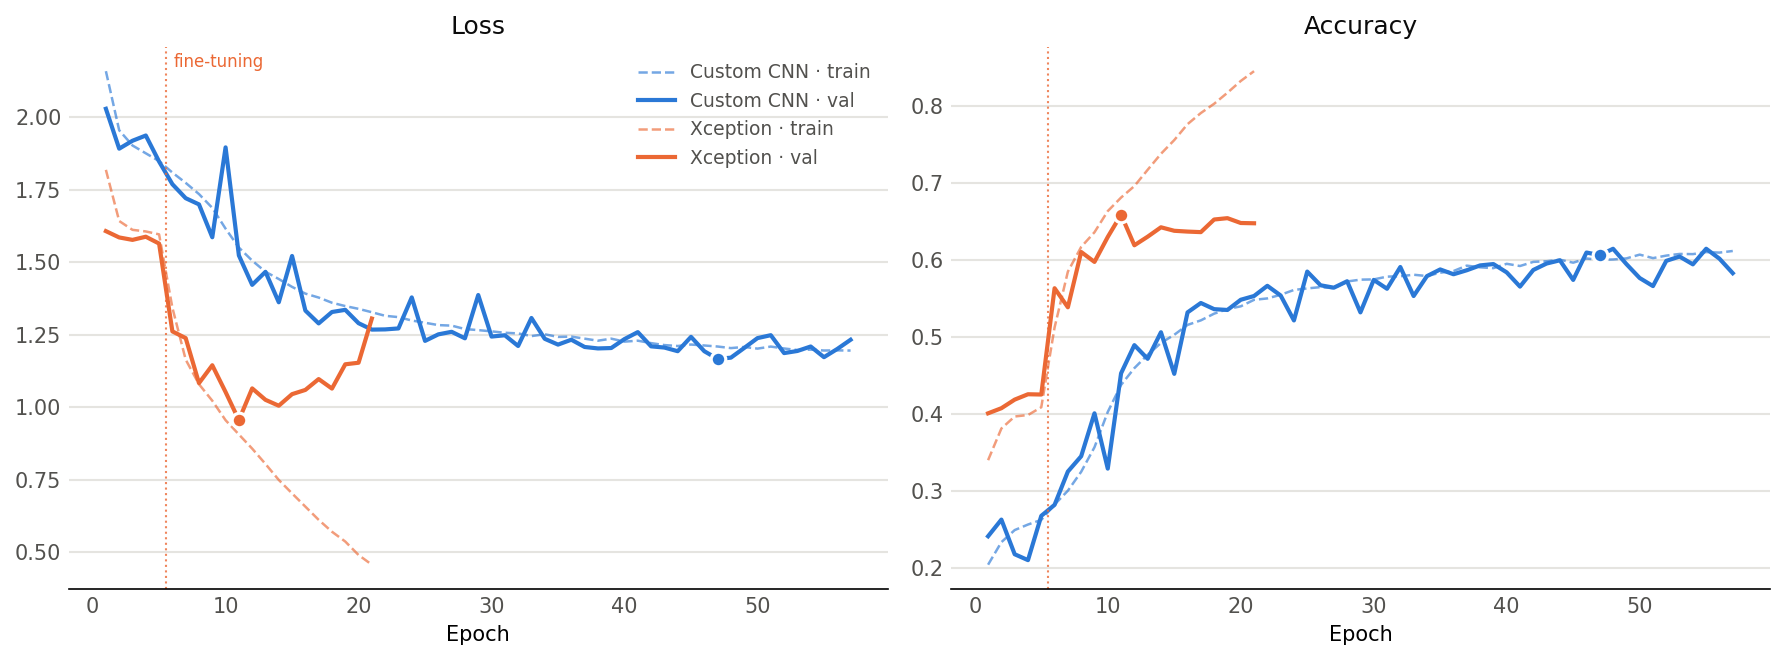

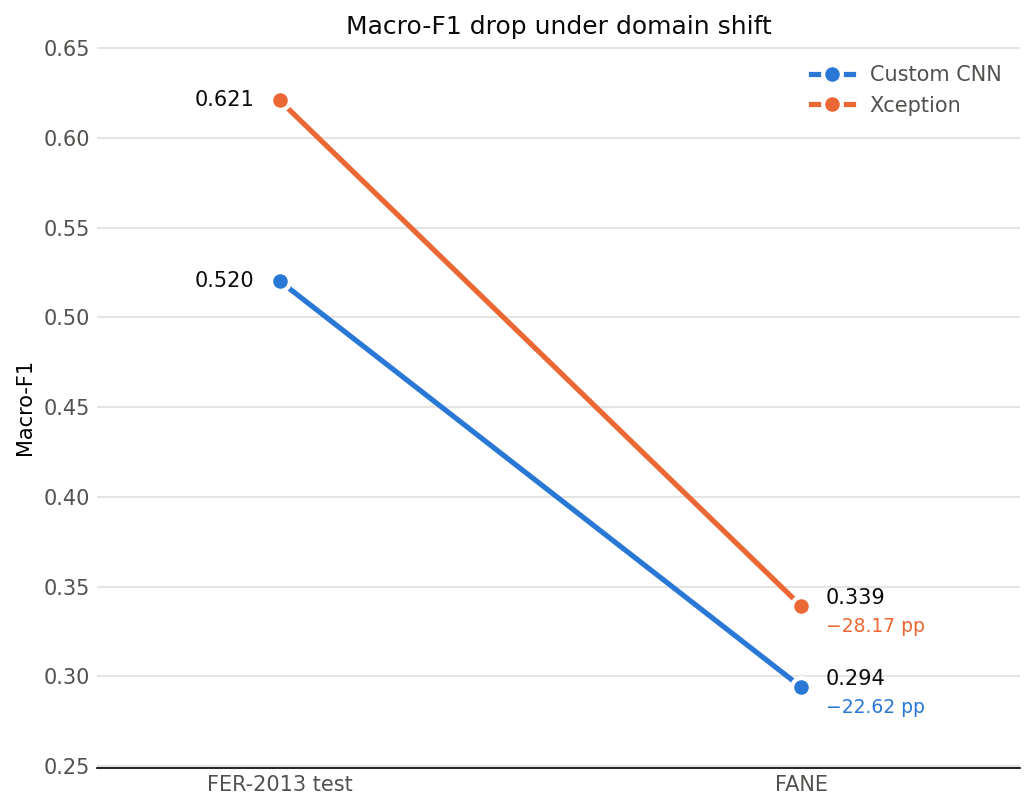

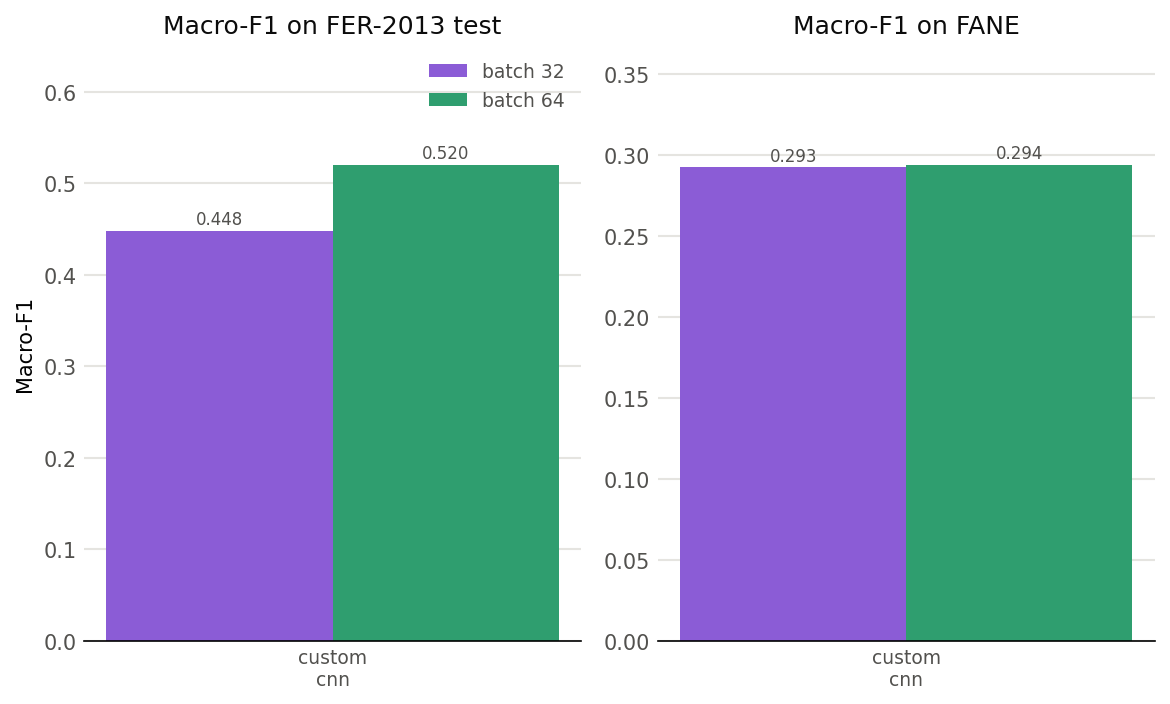

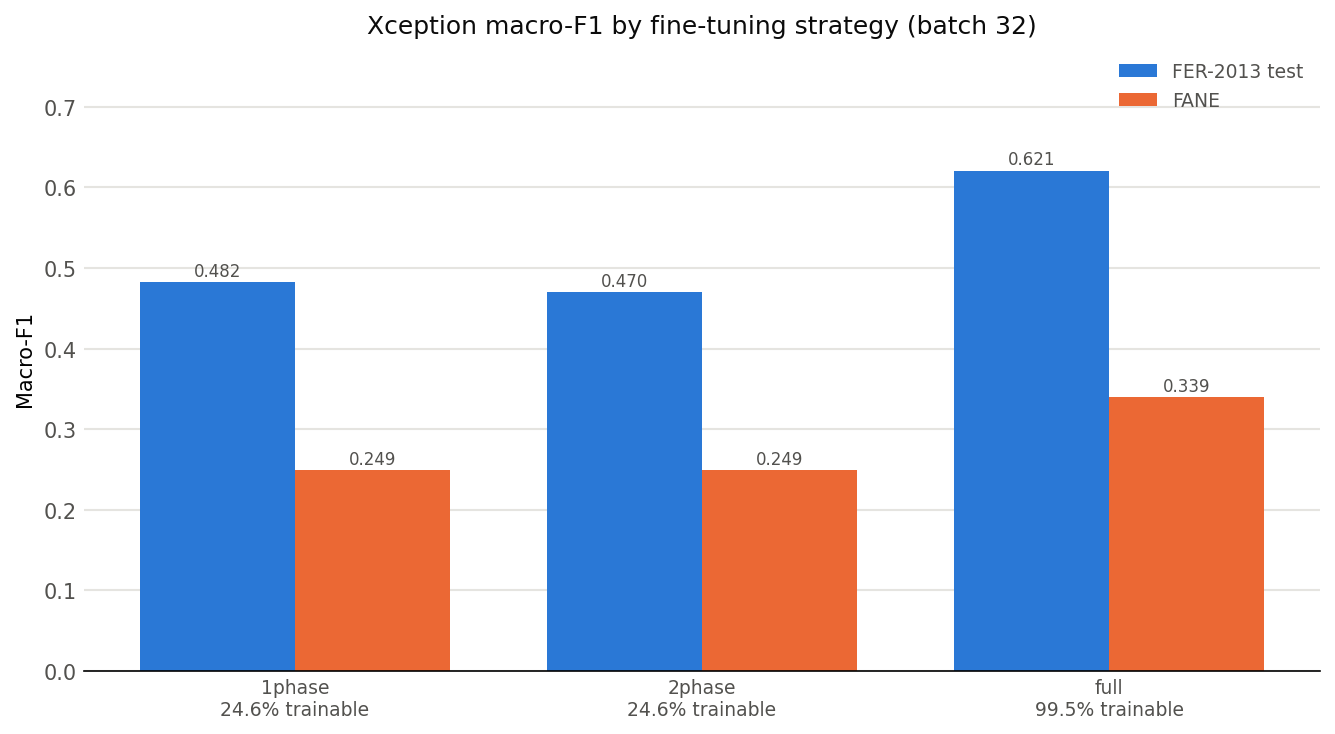

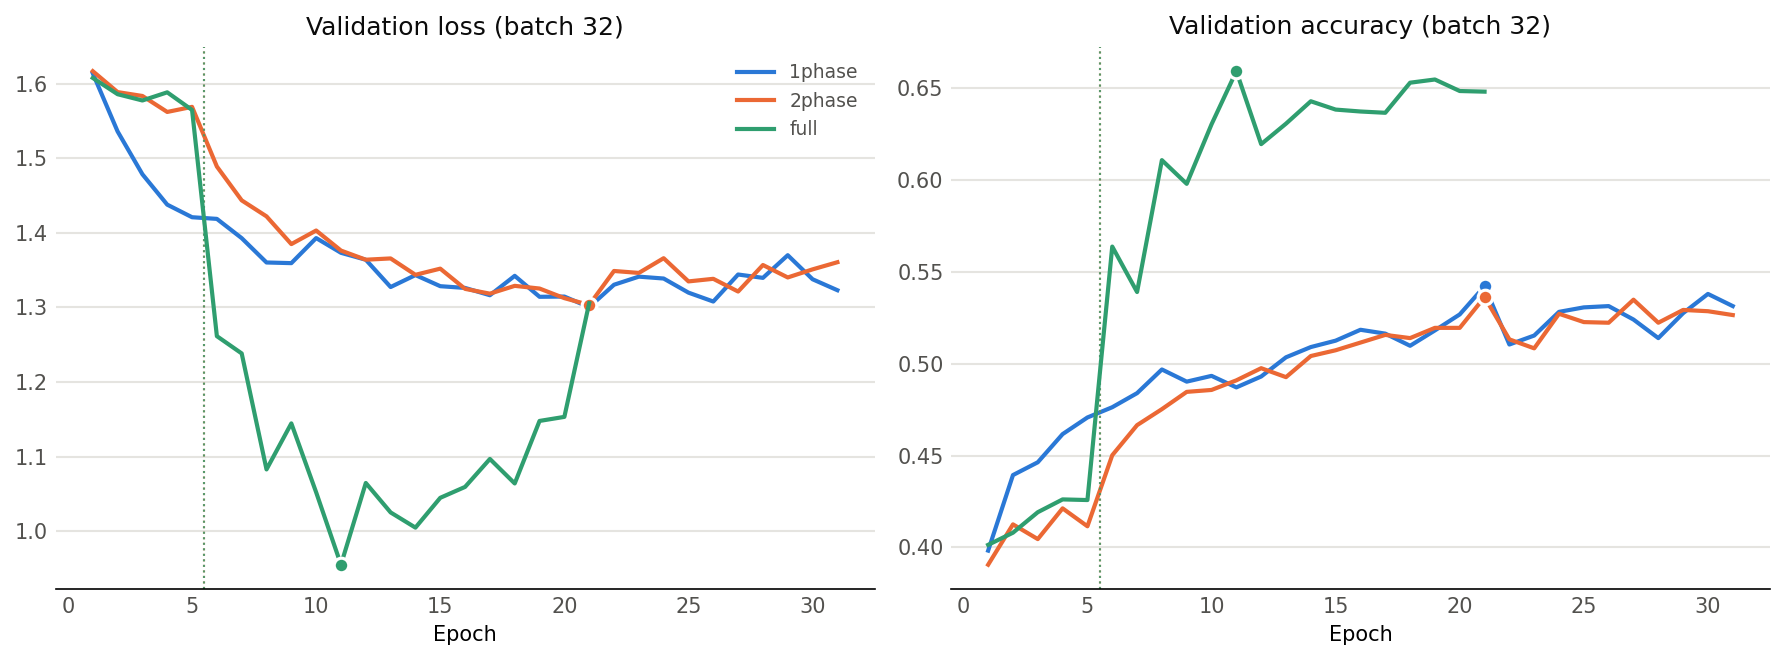

In [13]:
from IPython.display import Image, display

for table in ('all_runs.csv', 'batch_size_effect.csv', 'generalization_gap.csv'):
    print(table)
    display(pd.read_csv(METRICS / table))

for figure in ('training_curves.png', 'generalization_gap_slope.png',
               'batch_size_comparison.png', 'finetune_strategy.png',
               'xception_strategy_curves.png'):
    display(Image(str(FIGURES / figure)))